In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")
print(df[['Name', 'Club', 'Overall', 'Age', 'Wage', 'Value']].head())

Data loaded: 17660 players
              Name               Club  Overall  Age   Wage    Value
0      L. Goretzka  FC Bayern München       87   27  €115K     €91M
1  Bruno Fernandes  Manchester United       86   27  €190K   €78.5M
2         M. Acuña         Sevilla FC       85   30   €46K   €46.5M
3     K. De Bruyne    Manchester City       91   31  €350K  €107.5M
4       N. Barella              Inter       86   25  €110K   €89.5M


In [2]:
# Parse currency columns
def parse_currency(val):
    """Convert currency strings like '€115K' to numeric values"""
    if pd.isna(val) or val == '':
        return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val:
        return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val:
        return float(val.replace('K', '')) * 1_000
    else:
        return float(val) if val else np.nan

df['wage_numeric']  = df['Wage'].apply(parse_currency)
df['value_numeric'] = df['Value'].apply(parse_currency)

# Clean dataset: remove players without club or wage
df_clean = df[
    df['Club'].notna() &
    (df['Overall'] >= 50) &
    df['wage_numeric'].notna()
].copy()

print(f"Clean dataset: {df_clean.shape[0]} players across {df_clean['Club'].nunique()} clubs")

Clean dataset: 17097 players across 926 clubs


In [3]:
# ── Top Clubs by Average Overall Rating ──────────────────────────────────────
# Only clubs with at least 11 players (full squad)
club_stats = (
    df_clean.groupby('Club')
    .agg(
        avg_overall   = ('Overall',      'mean'),
        avg_age       = ('Age',          'mean'),
        total_wage    = ('wage_numeric',  'sum'),
        avg_wage      = ('wage_numeric',  'mean'),
        squad_size    = ('Name',         'count'),
        avg_value     = ('value_numeric', 'mean'),
        total_value   = ('value_numeric', 'sum')
    )
    .reset_index()
)
club_stats = club_stats[club_stats['squad_size'] >= 11]

top_clubs = club_stats.nlargest(20, 'avg_overall')
print("Top 20 Clubs by Average Overall Rating:")
print(top_clubs[['Club', 'avg_overall', 'squad_size', 'avg_age']].to_string(index=False))

fig = px.bar(
    top_clubs,
    x='avg_overall', y='Club',
    orientation='h',
    color='avg_overall',
    color_continuous_scale='Blues',
    text='avg_overall',
    title='Top 20 Clubs — Average Squad Overall Rating',
    labels={'avg_overall': 'Avg Overall', 'Club': ''},
    template='plotly_dark'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(
    coloraxis_showscale=False,
    height=580,
    yaxis={'categoryorder': 'total ascending'},
    xaxis_range=[60, top_clubs['avg_overall'].max() + 2]
)
fig.show()

Top 20 Clubs by Average Overall Rating:
               Club  avg_overall  squad_size   avg_age
              Inter    78.666667          33 27.757576
       AFC Richmond    78.066667          15 27.400000
      Villarreal CF    78.040000          25 26.320000
Paris Saint-Germain    77.897436          39 26.230769
           Juventus    77.750000          32 26.031250
  FC Bayern München    77.393939          33 25.242424
           AC Milan    77.312500          32 26.562500
             Napoli    76.583333          24 25.291667
    Manchester City    76.470588          34 24.735294
         SL Benfica    76.406250          32 26.250000
       FC Barcelona    76.195652          46 24.565217
  Tottenham Hotspur    75.828571          35 24.657143
     Real Madrid CF    75.650000          40 24.375000
         Sevilla FC    75.366667          30 26.933333
  Borussia Dortmund    75.081081          37 24.675676
          Liverpool    75.027778          36 24.638889
Bayer 04 Leverkusen    74

In [4]:
# ── Wage Bill vs Squad Quality ────────────────────────────────────────────────
# Are clubs paying proportionally for their quality?
club_stats['weekly_wage_bill_m'] = club_stats['total_wage'] / 1_000_000
club_stats['total_value_m']      = club_stats['total_value'] / 1_000_000

fig = px.scatter(
    club_stats,
    x='weekly_wage_bill_m',
    y='avg_overall',
    size='squad_size',
    color='avg_overall',
    color_continuous_scale='RdYlGn',
    hover_data=['Club', 'squad_size', 'avg_age'],
    text='Club',
    title='Weekly Wage Bill (€M) vs Average Squad Rating',
    labels={
        'weekly_wage_bill_m': 'Weekly Wage Bill (€M)',
        'avg_overall': 'Avg Overall Rating'
    },
    template='plotly_dark'
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(coloraxis_showscale=False, height=580, showlegend=False)
fig.show()

# Value for money: rating per €M of weekly wage
club_stats['value_for_money'] = club_stats['avg_overall'] / (club_stats['weekly_wage_bill_m'] + 0.01)
best_value = club_stats.nlargest(10, 'value_for_money')
worst_value = club_stats.nsmallest(10, 'value_for_money')

print("\n=== BEST VALUE CLUBS (High Rating, Low Wage Bill) ===")
print(best_value[['Club', 'avg_overall', 'weekly_wage_bill_m', 'value_for_money']].to_string(index=False))

print("\n=== WORST VALUE CLUBS (Low Rating, High Wage Bill) ===")
print(worst_value[['Club', 'avg_overall', 'weekly_wage_bill_m', 'value_for_money']].to_string(index=False))



=== BEST VALUE CLUBS (High Rating, Low Wage Bill) ===
                            Club  avg_overall  weekly_wage_bill_m  value_for_money
               Cusco Fútbol Club    61.083333             0.00600      3817.708333
            Mamelodi Sundowns FC    66.076923             0.00750      3775.824176
                    Club Guaraní    59.153846             0.00650      3585.081585
                      Royal Pari    64.437500             0.00800      3579.861111
                 Deportivo Pasto    60.916667             0.00710      3562.378168
                 Ferencvárosi TC    67.400000             0.00895      3556.728232
                     Dynamo Kyiv    69.937500             0.01010      3479.477612
Universidad Técnica de Cajamarca    62.562500             0.00800      3475.694444
                   Kaizer Chiefs    61.133333             0.00760      3473.484848
                      Sport Boys    63.117647             0.00850      3411.764706

=== WORST VALUE CLUBS (Low Rati

In [5]:
# ── Top Clubs by Total Squad Market Value ────────────────────────────────────
top_value_clubs = club_stats.nlargest(20, 'total_value_m')

fig = px.bar(
    top_value_clubs,
    x='total_value_m', y='Club',
    orientation='h',
    color='total_value_m',
    color_continuous_scale='Oranges',
    text='total_value_m',
    title='Top 20 Clubs — Total Squad Market Value (€M)',
    labels={'total_value_m': 'Total Value (€M)', 'Club': ''},
    template='plotly_dark'
)
fig.update_traces(texttemplate='€%{text:.0f}M', textposition='outside')
fig.update_layout(
    coloraxis_showscale=False,
    height=580,
    yaxis={'categoryorder': 'total ascending'}
)
fig.show()

In [6]:
# ── Which Clubs Have the Most Hidden Gems? ───────────────────────────────────
# Hidden gems: age ≤ 23, potential ≥ 80, overall < 78
gems = df_clean[
    (df_clean['Age'] <= 23) &
    (df_clean['Potential'] >= 80) &
    (df_clean['Overall'] < 78)
].copy()

gems_by_club = (
    gems.groupby('Club')
    .agg(gem_count=('Name', 'count'), avg_potential=('Potential', 'mean'))
    .reset_index()
    .sort_values('gem_count', ascending=False)
    .head(20)
)

print(f"Total hidden gems found: {len(gems)}")
print("\nTop 20 Clubs by Number of Hidden Gems:")
print(gems_by_club.to_string(index=False))

fig = px.bar(
    gems_by_club,
    x='gem_count', y='Club',
    orientation='h',
    color='avg_potential',
    color_continuous_scale='Greens',
    text='gem_count',
    title='Top 20 Clubs with Most Hidden Gems (Age ≤23, Potential ≥80, Overall <78)',
    labels={'gem_count': 'Hidden Gems', 'Club': '', 'avg_potential': 'Avg Potential'},
    template='plotly_dark'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    height=580,
    yaxis={'categoryorder': 'total ascending'}
)
fig.show()

Total hidden gems found: 887

Top 20 Clubs by Number of Hidden Gems:
                   Club  gem_count  avg_potential
      Manchester United         15      82.600000
                   Ajax         15      83.266667
   FC Red Bull Salzburg         14      82.214286
          VfL Wolfsburg         12      82.416667
           FC Barcelona         11      83.181818
              Feyenoord         10      82.100000
           Leeds United         10      82.000000
                   Roma         10      81.500000
                    PSV         10      83.700000
              AS Monaco         10      81.900000
      Borussia Dortmund         10      83.900000
            Valencia CF         10      82.000000
 Brighton & Hove Albion         10      82.100000
      Tottenham Hotspur          9      82.777778
                Chelsea          9      82.444444
        Manchester City          9      82.777778
               OGC Nice          9      81.333333
         RSC Anderlecht        

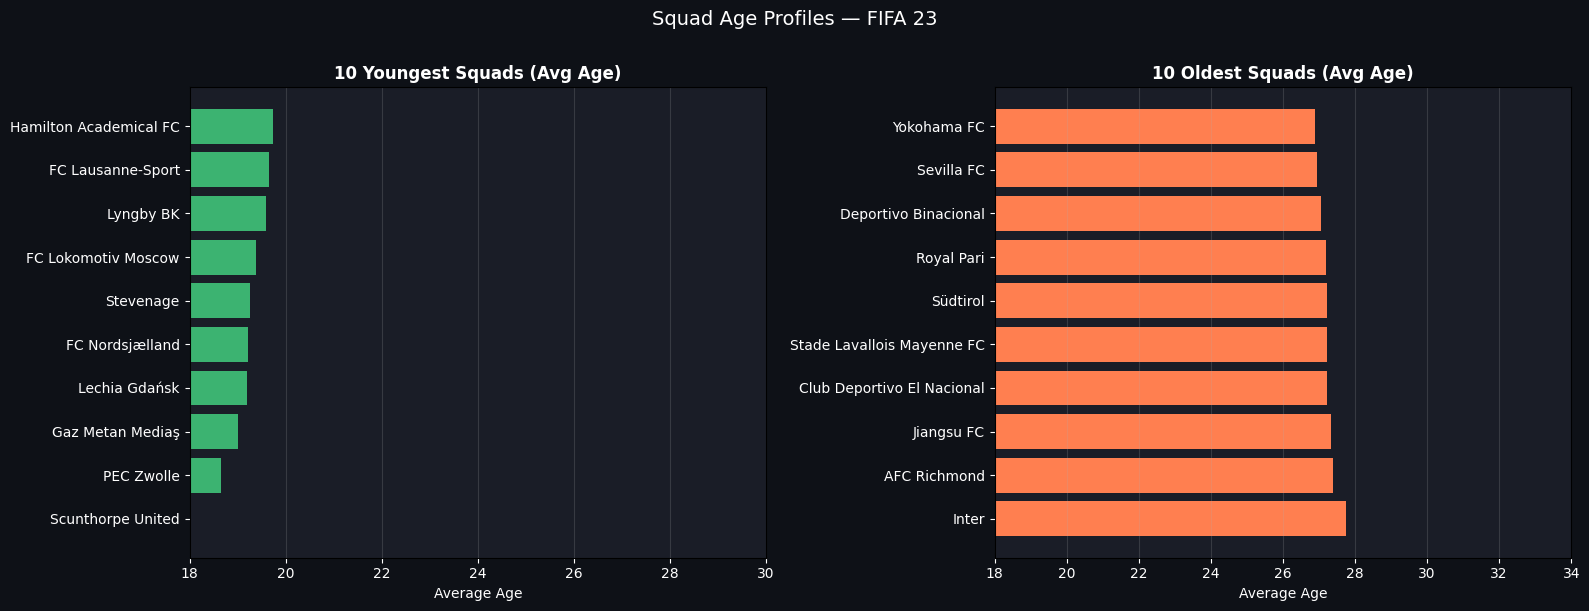


10 Youngest Squads:
                  Club   avg_age  avg_overall
     Scunthorpe United 17.461538    52.076923
            PEC Zwolle 18.650000    59.400000
      Gaz Metan Mediaş 19.000000    54.937500
         Lechia Gdańsk 19.187500    58.000000
       FC Nordsjælland 19.217391    58.304348
             Stevenage 19.266667    54.200000
   FC Lokomotiv Moscow 19.375000    61.875000
             Lyngby BK 19.600000    56.000000
     FC Lausanne-Sport 19.647059    56.176471
Hamilton Academical FC 19.727273    55.818182

10 Oldest Squads:
                      Club   avg_age  avg_overall
                     Inter 27.757576    78.666667
              AFC Richmond 27.400000    78.066667
                Jiangsu FC 27.333333    62.523810
Club Deportivo El Nacional 27.235294    62.117647
Stade Lavallois Mayenne FC 27.217391    63.478261
                  Südtirol 27.214286    64.000000
                Royal Pari 27.187500    64.437500
      Deportivo Binacional 27.047619    61.714286
    

In [7]:
# ── Squad Age Profile: Young vs Experienced Clubs ────────────────────────────
youngest_clubs = club_stats.nsmallest(10, 'avg_age')[['Club', 'avg_age', 'avg_overall']]
oldest_clubs   = club_stats.nlargest(10, 'avg_age')[['Club', 'avg_age', 'avg_overall']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0e1117')
for ax in axes:
    ax.set_facecolor('#1a1d27')

# Youngest clubs
axes[0].barh(youngest_clubs['Club'], youngest_clubs['avg_age'], color='mediumseagreen', edgecolor='none')
axes[0].set_title('10 Youngest Squads (Avg Age)', color='white', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Age', color='white')
axes[0].tick_params(colors='white')
axes[0].grid(axis='x', alpha=0.2)
axes[0].set_xlim(18, 30)

# Oldest clubs
axes[1].barh(oldest_clubs['Club'], oldest_clubs['avg_age'], color='coral', edgecolor='none')
axes[1].set_title('10 Oldest Squads (Avg Age)', color='white', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Age', color='white')
axes[1].tick_params(colors='white')
axes[1].grid(axis='x', alpha=0.2)
axes[1].set_xlim(18, 34)

plt.suptitle('Squad Age Profiles — FIFA 23', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n10 Youngest Squads:")
print(youngest_clubs.to_string(index=False))
print("\n10 Oldest Squads:")
print(oldest_clubs.to_string(index=False))